[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JulesMalin/isba2411-nlp/blob/main/Week%206/L11_Follow_Along_Transformers.ipynb)

# ISBA 2411 · Week 6 · Lecture 11
## Looking Inside the Model — a follow-along

This notebook is the deck, made runnable. We use the **same use case** as the slides — an
app-store **review responder** — and open a real transformer (**GPT-2**) to watch every step
we drew: tokens become vectors, attention scores which words matter, the forward pass scores
the next token, and a loop writes the whole reply.

**How to run.** `Runtime -> Run all` now; the install and the model download (~500 MB) happen
while we talk. GPT-2 is small enough to run on a **free CPU runtime** — no GPU needed.

## 0 · Setup

Two libraries: `transformers` (the model) and `torch` (the math). We load GPT-2 with `output_attentions=True` so it hands back the attention weights we want to see.

In [ ]:
%pip install -q transformers torch matplotlib

import torch, numpy as np, matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

torch.manual_seed(0)
MODEL = "gpt2"                                  # the 124M decoder; runs on a free CPU runtime
tok = GPT2TokenizerFast.from_pretrained(MODEL)
model = GPT2LMHeadModel.from_pretrained(MODEL, output_attentions=True).eval()

cfg = model.config
print(f"{MODEL}: {cfg.n_layer} blocks, {cfg.n_head} heads per block, "
      f"d_model={cfg.n_embd}, vocab={cfg.vocab_size:,}")

**Reading it.** Those four numbers *are* GPT-2 (124M params): **12** transformer blocks stacked, each with **12** attention heads, all working with **768**-number vectors, over a **50,257**-token vocabulary. Every output in this notebook traces back to these four. The big models only change the numbers (more blocks, wider vectors) — not the machine.

## The use case

<div align="center">
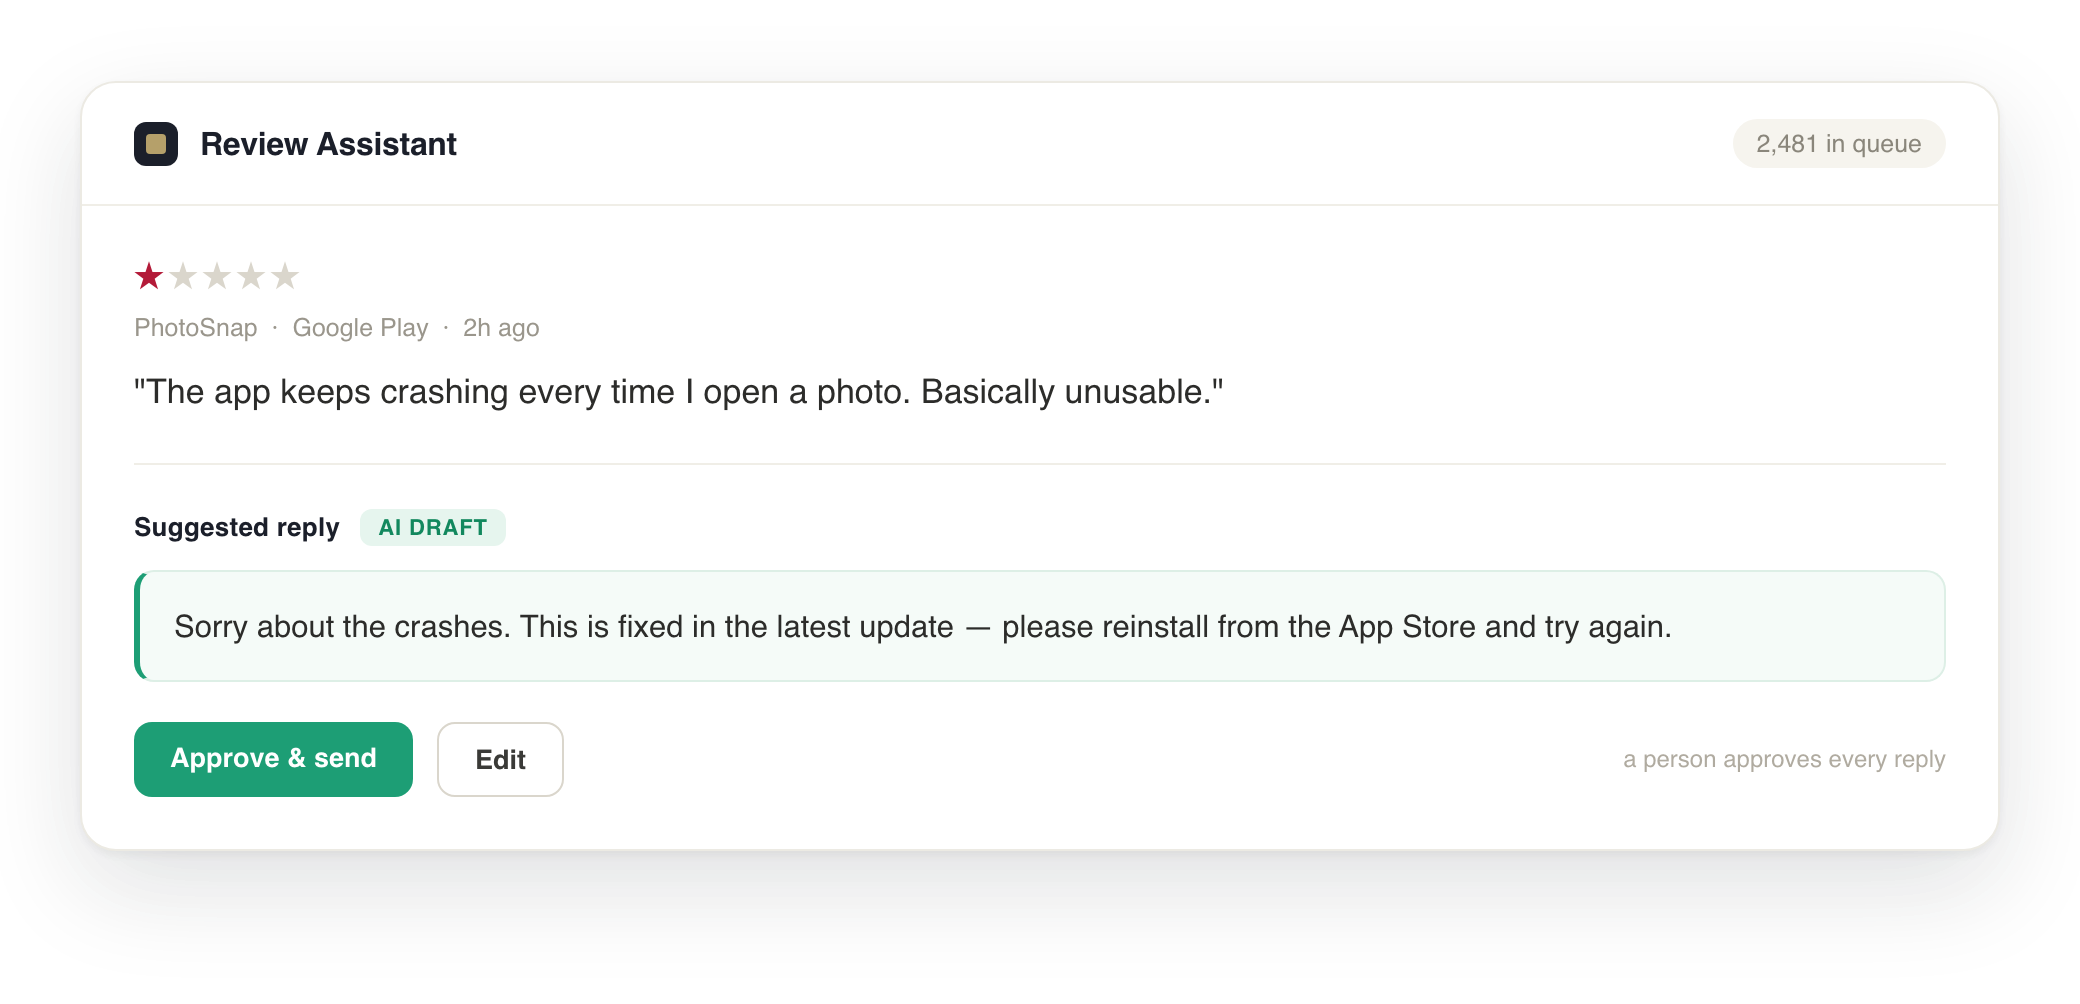<br>
<sub><i>The Review Assistant from slides 2–3. A 1-star review comes in; the model drafts a reply that answers the real complaint.</i></sub>
</div>

This is the review we work with all notebook. Everything below explains how a model turns *this* text into a reply that names the actual problem.

In [ ]:
review = "The app keeps crashing every time I open a photo. Basically unusable."
review

## The plan

<div align="center">
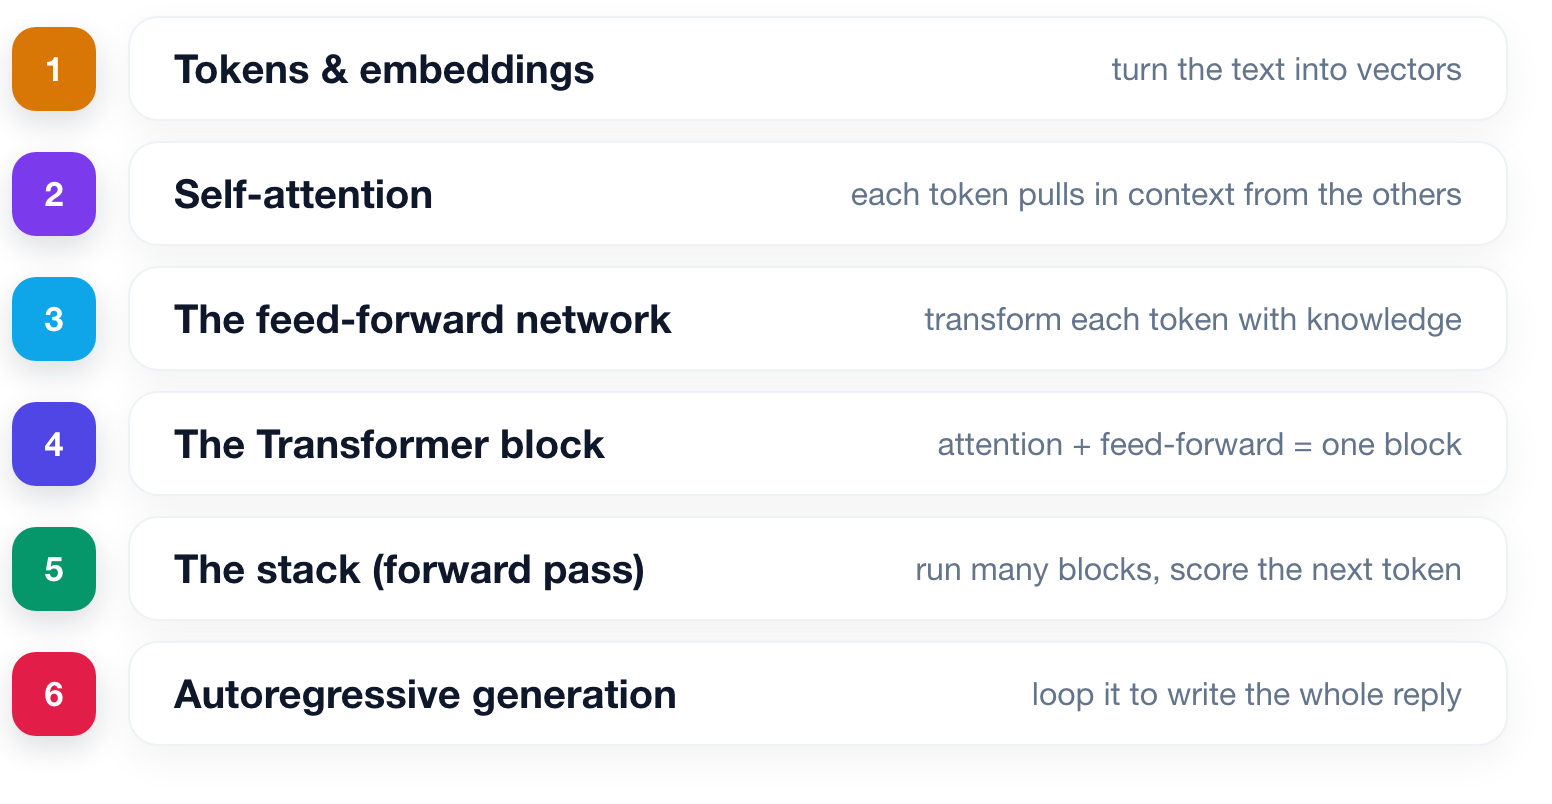<br>
<sub><i>The six steps from slide 4. We build straight up this ladder, one code section per rung.</i></sub>
</div>

Each step below is one rung: **1** tokens → **2** self-attention → **3** feed-forward → **4** the block → **5** the forward pass → **6** generation.

## Step 1 · Tokens & embeddings

<div align="center">
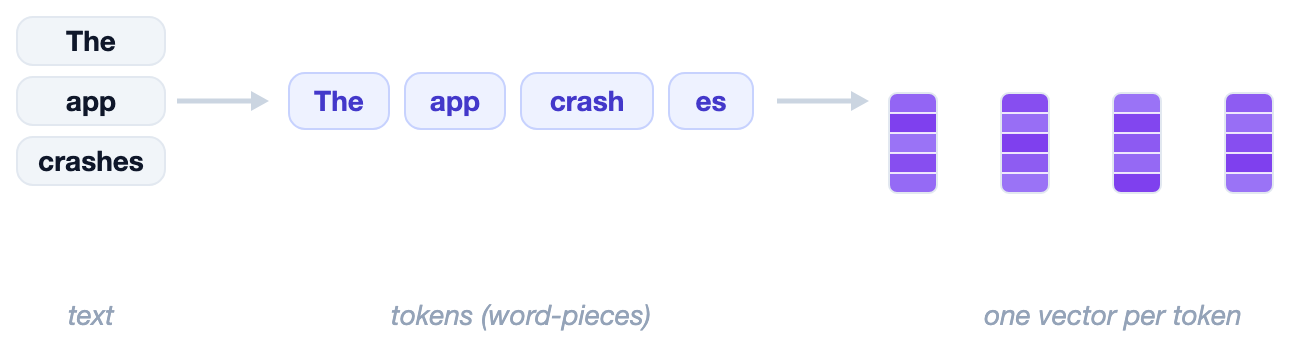<br>
<sub><i>Slide 5. Text is split into tokens (word-pieces for rare words), and each token looks up a learned vector.</i></sub>
</div>

First the tokenizer splits the text into **tokens**. Common words are whole; rarer ones break into pieces (watch what happens to *crashing* and *unusable*).

In [ ]:
ids = tok(review, return_tensors="pt").input_ids       # (1, seq) integer token ids
tokens = [tok.decode(i) for i in ids[0]]
print(f"{len(tokens)} tokens:")
print(tokens)

# see the split: one colored box per token id
fig, ax = plt.subplots(figsize=(min(13, 1.05 * len(tokens)), 1.15))
x = 0
for k, t in enumerate(tokens):
    w = max(0.7, 0.34 * len(t))
    ax.add_patch(plt.Rectangle((x, 0), w, 1, facecolor=plt.cm.Set3(k % 12), edgecolor="white"))
    ax.text(x + w / 2, 0.5, t.strip() or repr(t), ha="center", va="center", fontsize=11)
    x += w + 0.06
ax.set_xlim(0, x); ax.set_ylim(0, 1); ax.axis("off")
ax.set_title(f"{len(tokens)} tokens — each box is one id fed to the model")
plt.tight_layout(); plt.show()

**Reading it.** The sentence became a list of tokens. Common words stay whole; a rarer word breaks into word-pieces (watch `unusable`). A leading space is part of the token — ` app` is a *different* token from `app`. This is byte-pair encoding: a fixed ~50k vocabulary that can still spell any word.

Each token id then indexes a **learned embedding table** — one row per vocabulary entry — to become a vector of `d_model` numbers. That vector *is* the token's meaning, as far as the model is concerned.

In [ ]:
wte = model.transformer.wte.weight                     # (vocab, d_model) learned lookup table
print("embedding table:", tuple(wte.shape))

j = 1
vec = wte[ids[0, j]]
print(f"token {tokens[j]!r} -> a vector of {vec.shape[0]} numbers")
print("first 8:", vec[:8].detach().numpy().round(3))

# the whole vector as a color strip: each cell is one dimension, red/blue = +/-
m = float(vec.abs().max())
plt.figure(figsize=(12, 0.9))
plt.imshow(vec.detach().numpy()[None, :], aspect="auto", cmap="RdBu_r", vmin=-m, vmax=m)
plt.yticks([]); plt.xlabel(f"the {vec.shape[0]} learned dimensions of token {tokens[j].strip()!r}")
plt.title("one token id  ->  one 768-number vector"); plt.colorbar(fraction=0.02, pad=0.01)
plt.tight_layout(); plt.show()

**Reading it.** The table is `50257 × 768` — a learned row for every possible token. The strip is that one token's row (red positive, blue negative). Nothing here is hand-set: training nudged these numbers so that words used alike end up with similar strips.

## Step 2 · Self-attention

<div align="center">
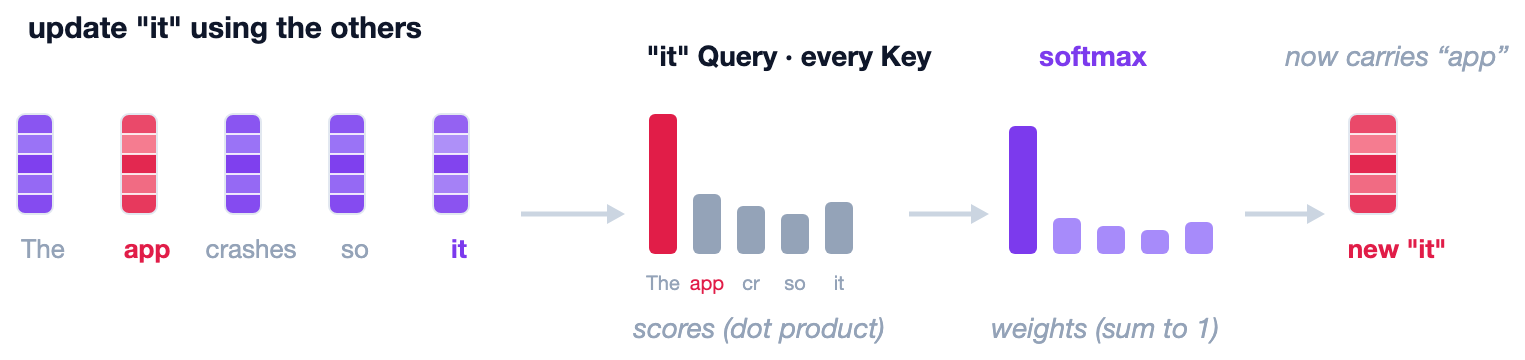<br>
<sub><i>Slide 6. Each token scores every other token, then blends them in — so a word absorbs its context.</i></sub>
</div>

Run the review through the model and ask for the **attention weights**. GPT-2 has 12 blocks, each with 12 heads; every head produces a `seq × seq` grid of how much each token attends to every other. Let's pull all of them out and look.

In [ ]:
with torch.no_grad():
    out = model(ids)

attn = out.attentions          # tuple of n_layer tensors, each (batch, n_head, seq, seq)
print(len(attn), "blocks, each of shape", tuple(attn[0].shape), " = (batch, heads, seq, seq)")

**What just happened, as a picture.** The forward pass produced one `seq × seq` attention map for *every* block and head. Here they all are at once — an 'attention atlas'. You do not read the details yet; just see that the model computed a whole stack of different patterns (some diagonal, some local, some global).

In [ ]:
# every attention map the forward pass produced: one tile per (block, head)
n_layer, n_head = len(attn), attn[0].shape[1]
fig, axes = plt.subplots(n_layer, n_head, figsize=(n_head * 0.7, n_layer * 0.7))
for L in range(n_layer):
    for h in range(n_head):
        ax = axes[L, h]
        ax.imshow(attn[L][0, h].numpy(), cmap="Purples", vmin=0)
        ax.set_xticks([]); ax.set_yticks([])
        if h == 0: ax.set_ylabel(f"block {L}", fontsize=6, rotation=0, ha="right", va="center")
        if L == 0: ax.set_title(f"h{h}", fontsize=6)
fig.suptitle(f"Attention atlas for this review: {n_layer} blocks x {n_head} heads = {n_layer * n_head} maps", y=1.003)
plt.tight_layout(); plt.show()

Now **zoom into one block** and label the tokens so we can actually read it. This heatmap is a single block's attention, averaged over its heads: **row = the token doing the looking, column = the token it looks at.** Brighter means more attention.

In [ ]:
labels = [t.strip() or t for t in tokens]

def plot_attention(A, title, cmap="Purples"):
    fig, ax = plt.subplots(figsize=(6.2, 5.2))
    im = ax.imshow(A, cmap=cmap, vmin=0)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel("attends to  ->"); ax.set_ylabel("query token")
    ax.set_title(title); fig.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()

layer = 5
plot_attention(attn[layer][0].mean(0).numpy(), f"Block {layer}: who attends to whom (averaged over heads)")

**What to notice.** The bright cells sit on or below the diagonal: a token can only attend *backward*, never to words that come after it (GPT-2 is a decoder — it writes left to right). Bright vertical bands mark tokens that many others lean on.

### Scaled dot-product attention

<div align="center">
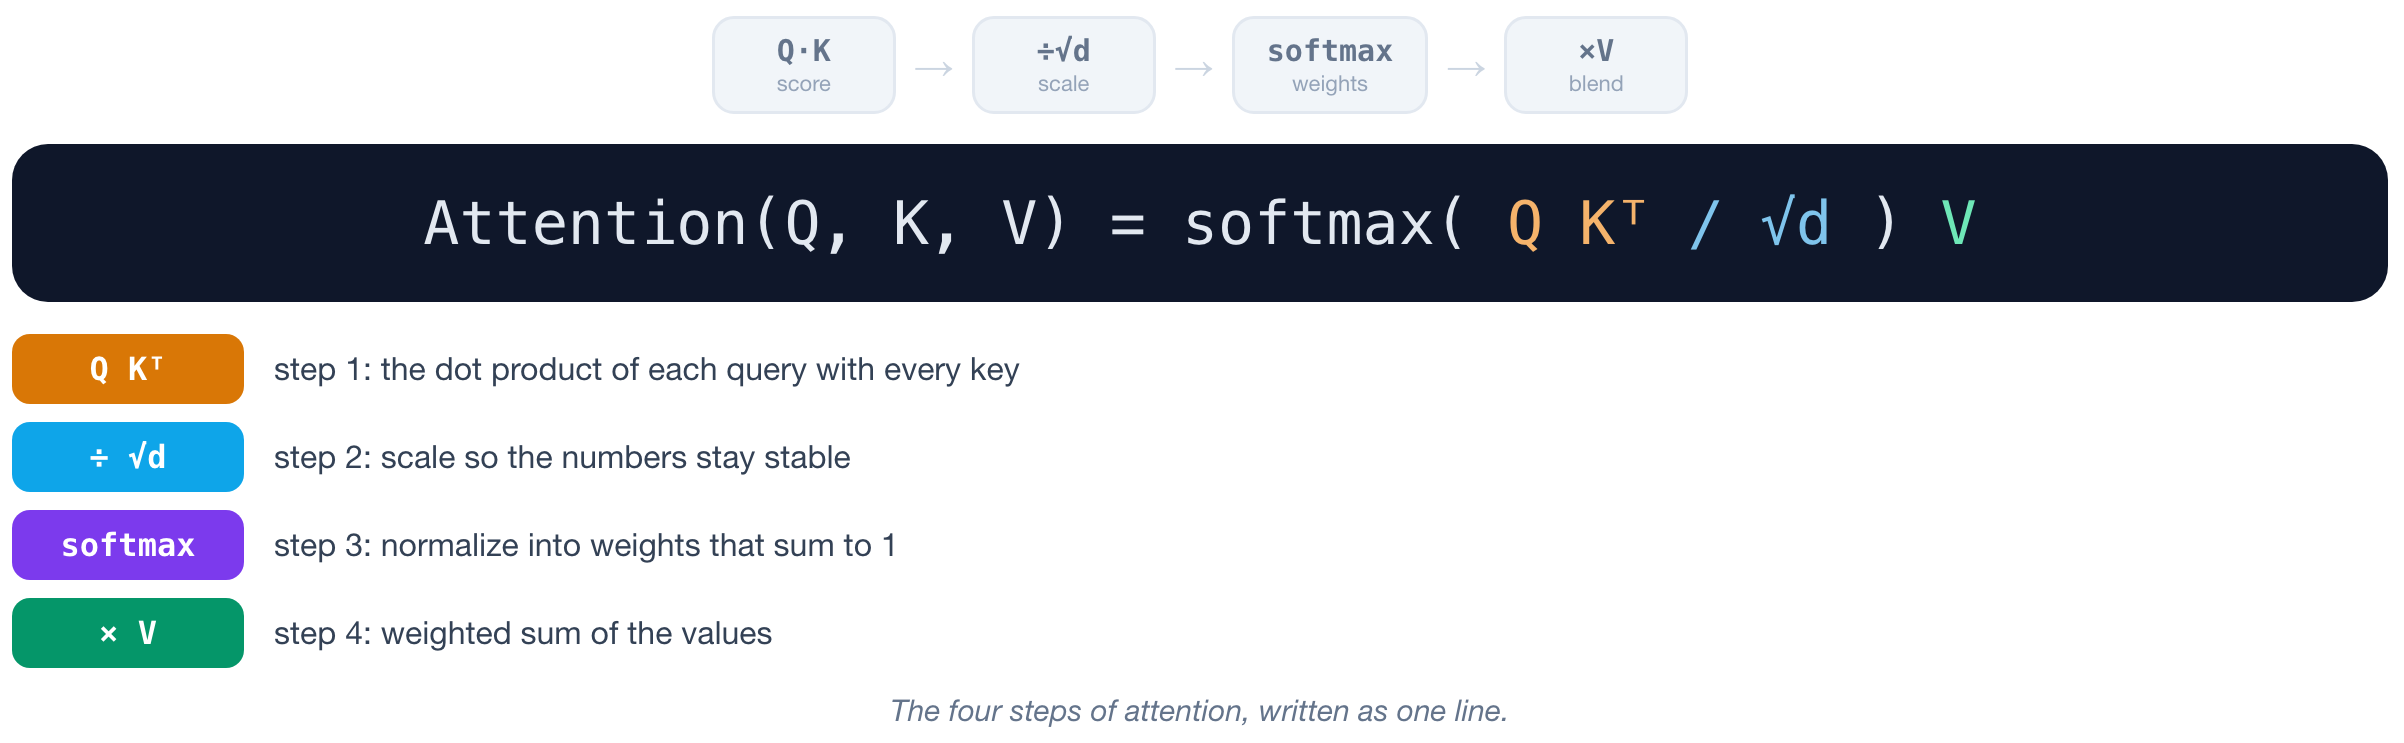<br>
<sub><i>Slide 7. The four steps of attention as one line: softmax(Q Kᵀ / √d) V.</i></sub>
</div>

Those weights come from one formula. Let's build it by hand on toy vectors so nothing is hidden — the same four steps as the slide.

In [ ]:
d = 8
q = torch.randn(1, d)          # one query
K = torch.randn(5, d)          # five keys
V = torch.randn(5, d)          # five values

scores  = (q @ K.T) / np.sqrt(d)     # step 1 & 2: dot product of q with every key, scaled by sqrt(d)
weights = torch.softmax(scores, -1)  # step 3: normalize into weights that sum to 1
context = weights @ V                # step 4: weighted sum of the values

print("scores :", scores.numpy().round(2))
print("weights:", weights.numpy().round(3), " sum =", round(weights.sum().item(), 3))
print("context:", context.numpy().round(2)[0])

# the weights as a bar: how much of each value flows into the blend
plt.figure(figsize=(6, 2.8))
plt.bar(range(weights.shape[1]), weights[0].numpy(), color="#7C3AED")
plt.xticks(range(weights.shape[1]), [f"key {i}" for i in range(weights.shape[1])])
plt.ylabel("weight"); plt.ylim(0, 1); plt.title("softmax weights (sum to 1)")
plt.tight_layout(); plt.show()

**Reading it.** Five raw `scores` (the dot products) became five `weights` that sum to 1. The tallest bar is the key whose direction best lined up with the query. `context` is the values blended by those weights — the query mostly pulled in the single value it scored highest. That is the whole of attention, just on toy numbers.

**Why divide by √d?** Without it, the dot products grow with the dimension, softmax saturates onto one token, and gradients vanish. The scale keeps the scores in a sane range — let's measure that.

In [ ]:
dims = [8, 32, 128, 512]
raw_std, scaled_std = [], []
for dim in dims:
    q = torch.randn(4000, dim); k = torch.randn(4000, dim)
    dots = (q * k).sum(-1)                              # 4000 dot products at this dimension
    raw_std.append(dots.std().item()); scaled_std.append((dots / np.sqrt(dim)).std().item())
    print(f"d={dim:4d}:  raw std ~ {raw_std[-1]:6.1f}   |   /sqrt(d) ~ {scaled_std[-1]:.2f}")

x = np.arange(len(dims)); fig, ax = plt.subplots(figsize=(6.5, 3))
ax.bar(x - 0.2, raw_std, 0.4, color="#E11D48", label="raw  Q·K")
ax.bar(x + 0.2, scaled_std, 0.4, color="#059669", label="scaled  Q·K / sqrt(d)")
ax.set_xticks(x); ax.set_xticklabels([f"d={d}" for d in dims]); ax.set_ylabel("spread (std) of scores")
ax.set_title("without scaling, scores blow up as d grows"); ax.legend()
plt.tight_layout(); plt.show()

**Reading it.** The red bars climb with dimension — raw scores spread wider and wider — while the green bars stay near 1. At `d=768`, unscaled scores would be large enough that softmax spikes to ~1.0 on a single token and the gradient dies. Dividing by √d is the one-line fix that keeps every dimension trainable.

## Multi-head attention

<div align="center">
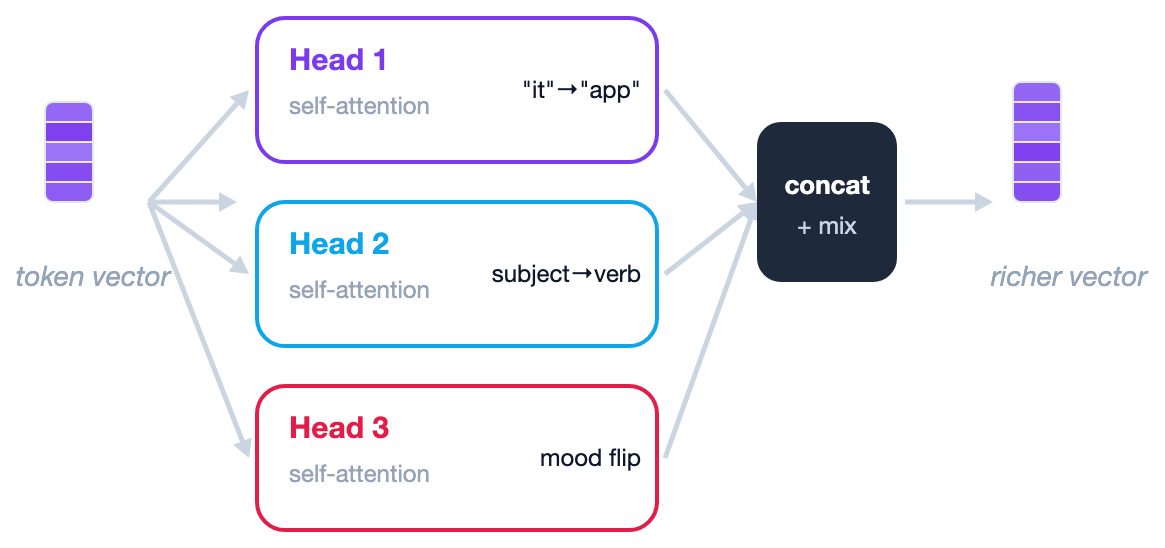<br>
<sub><i>Slide 8. Many heads run in parallel; each learns a different relationship.</i></sub>
</div>

Attention runs many times in parallel. Same input, same block — but each **head** has learned to look for something different. Here are four heads from one block:

In [ ]:
layer = 0
heads = attn[layer][0]                 # (n_head, seq, seq)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for h, ax in enumerate(axes):
    ax.imshow(heads[h].numpy(), cmap="Purples", vmin=0)
    ax.set_title(f"head {h}")
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=7)
plt.suptitle(f"Block {layer}: four heads, four different patterns", y=1.02)
plt.tight_layout(); plt.show()

**What to notice.** Same tokens, one block, four heads — four different pictures. One may run along the diagonal (attend to the previous word), another may pile onto the first token, another may spread wide. Nobody assigned these roles; each head's own Q/K/V matrices *learned* them. Concatenating the heads is how one block tracks several relationships at once.

## Step 3 · The feed-forward network

<div align="center">
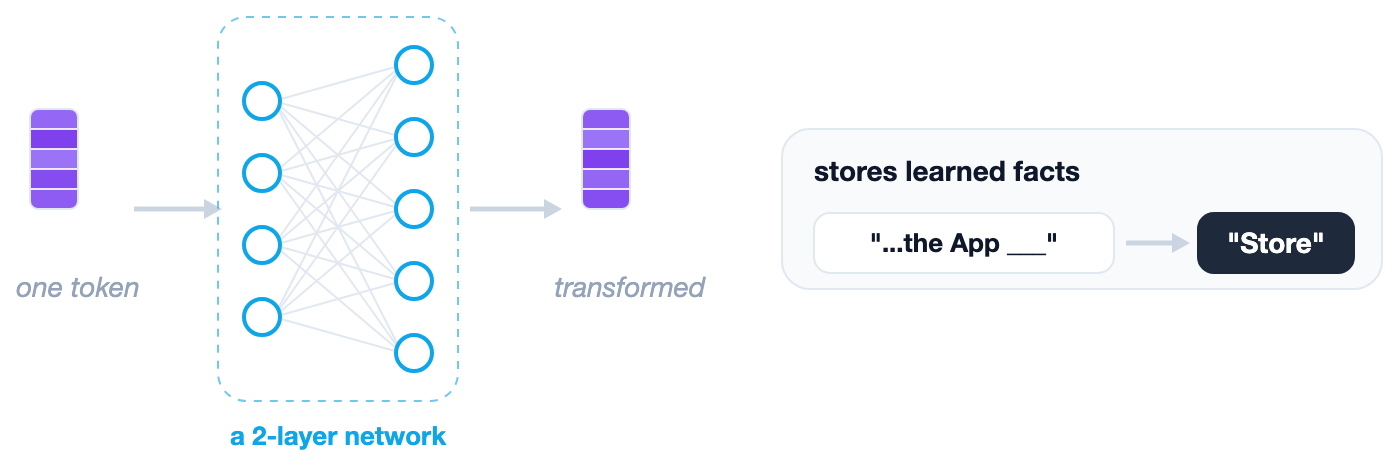<br>
<sub><i>Slide 9. A small 2-layer network applied to each token on its own — where learned facts live.</i></sub>
</div>

After attention mixes the tokens, a **feed-forward network** processes each one on its own. It is just two linear layers: expand to 4× width, then back. This is where much of the model's stored knowledge lives.

In [ ]:
block0 = model.transformer.h[0]
print("FFN layer 1 (c_fc)  :", tuple(block0.mlp.c_fc.weight.shape),  " <- d_model -> 4 x d_model")
print("FFN layer 2 (c_proj):", tuple(block0.mlp.c_proj.weight.shape), " <- 4 x d_model -> d_model")
print("\nSame two-layer network is applied at every token position, independently.")

**Reading it.** `768 -> 3072 -> back to 768`: the middle is 4× wider. These two matrices alone hold roughly **two-thirds** of GPT-2's parameters. Attention decides *what to mix*; this feed-forward network is where most of the *stored knowledge* lives (slide 9's 'download it from the App ___ -> Store').

## Step 4 · The Transformer block

<div align="center">
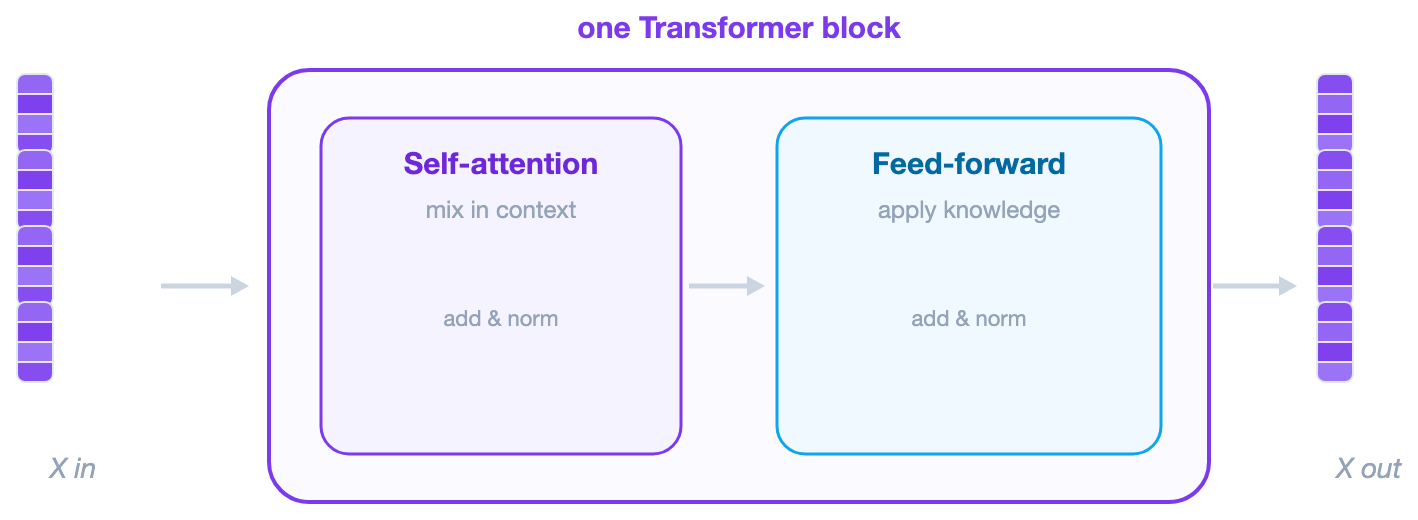<br>
<sub><i>Slide 10. Attention + feed-forward, with add-and-norm, is one block. GPT-2 stacks 12 of them.</i></sub>
</div>

One **block** = self-attention (mix tokens) then the feed-forward network (process each), each wrapped in a residual add-and-norm. The whole model is just this block, stacked.

In [ ]:
print(block0)     # ln_1 -> attn -> ln_2 -> mlp
print(f"\nGPT-2 stacks {model.config.n_layer} of these blocks. The big models stack dozens more.")

**Reading it.** `ln_1 -> attn -> ln_2 -> mlp`, each sublayer wrapped in a residual add. That is the *entire* repeating unit. 'A deep model' just means this same block run 12 times (or 32, or 80) back to back — nothing new is bolted on, it is stacked.

## Step 5 · The forward pass

<div align="center">
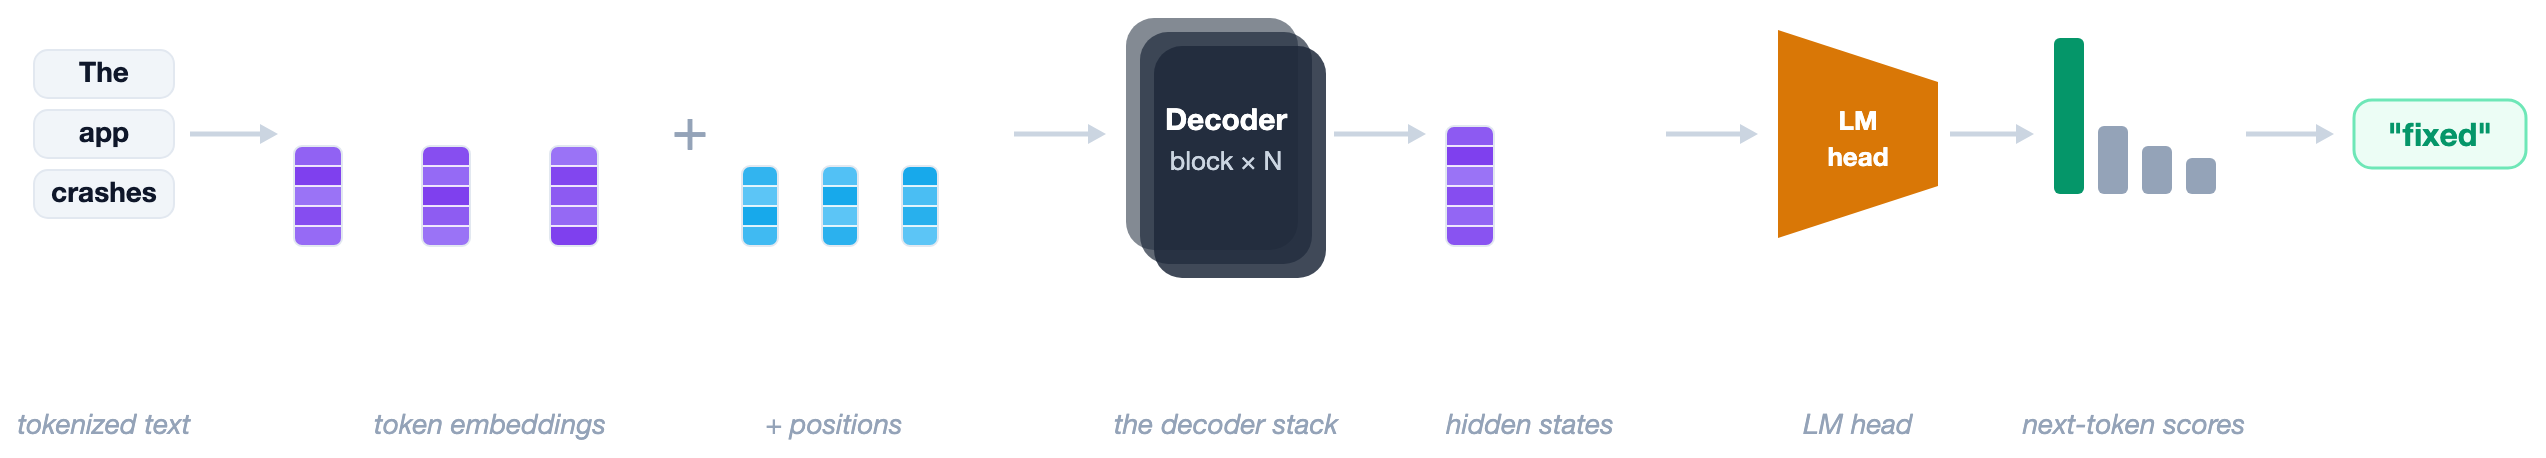<br>
<sub><i>Slide 11. Tokens go up the stack; the final vector hits the LM head, which scores the whole vocabulary.</i></sub>
</div>

Now run the whole thing. We feed the review plus the start of a reply, and read the **LM head**: a score for every one of the 50,257 tokens for what comes next. Softmax turns those into probabilities.

In [ ]:
prompt = ('App review: "The app keeps crashing every time I open a photo. Basically unusable."\n'
          'Developer reply: "Sorry about the')
pids = tok(prompt, return_tensors="pt").input_ids

with torch.no_grad():
    logits = model(pids).logits            # (1, seq, vocab): the LM head output at every position
probs = torch.softmax(logits[0, -1], -1)   # distribution over the *next* token

print("Top candidates for the next token:")
top = torch.topk(probs, 8)
for p, i in zip(top.values, top.indices):
    print(f"  {tok.decode(i)!r:14} {p.item():.3f}")

# the same distribution as a bar chart
labs = [tok.decode(i).strip() or tok.decode(i) for i in top.indices]
y = np.arange(len(labs))
plt.figure(figsize=(7, 3))
plt.barh(y, top.values.numpy(), color="#059669")
plt.gca().invert_yaxis()                     # highest probability on top
plt.yticks(y, labs); plt.xlabel("probability")
plt.title('next token after "...Sorry about the"')
plt.tight_layout(); plt.show()

**Reading it — this is the payoff.** Given only `Sorry about the`, the model's top guesses are `app`, `issue`, `crash`, `problem`. It already wants to name the complaint. Nothing told it the review was about crashing — **attention carried those review words forward** through all 12 blocks into this one distribution. That is slide 6's promise, measured.

## Step 6 · Autoregressive generation

<div align="center">
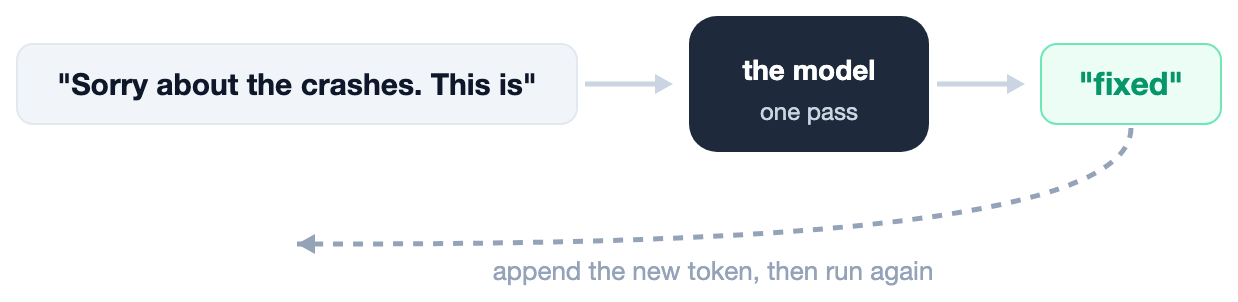<br>
<sub><i>Slide 12. Pick a token, append it, run again. Looping the forward pass writes the whole reply.</i></sub>
</div>

Generation is just that forward pass in a loop: **score → pick one → append → repeat.** Here is the loop written out by hand (greedy: always take the top token).

In [ ]:
ids_gen = pids.clone()
for _ in range(12):
    with torch.no_grad():
        next_logits = model(ids_gen).logits[0, -1]
    nxt = torch.argmax(next_logits)                       # greedy pick
    ids_gen = torch.cat([ids_gen, nxt.view(1, 1)], dim=1) # append, then the loop runs again

print(tok.decode(ids_gen[0]))

**Reading it.** Greedy decoding (always take the single top token) is fluent but gets stuck in a loop — *'sorry about the app crashing. I'm sorry about the app crashing.'* That repetition is a well-known failure of always-take-the-top, and it is exactly why real generation **samples** instead — the next cell.

`model.generate` is the same loop, with **sampling** (temperature / top-p) instead of always taking the top token, so the text is less repetitive.

> GPT-2 is tiny and not instruction-tuned, so the reply is rough. The **mechanism** is exactly what a large, tuned model runs to write a genuinely good reply.

In [ ]:
out_ids = model.generate(pids, max_new_tokens=40, do_sample=True,
                         temperature=0.7, top_p=0.9, pad_token_id=tok.eos_token_id)
print(tok.decode(out_ids[0]))

## Full circle — how did it know which words mattered?

Back to the question from the very start (slide 3): the reply nailed the **specific** complaint. Let's watch
it happen. We feed the model the **review and a drafted reply together**, then ask one precise question:
*when the reply reaches the word "crashes", which earlier words is it looking at?*

**What the next cell does, step by step:**
1. Glue the review and the reply into one string and tokenize it.
2. Run the model once and keep all the attention weights — 12 layers × 12 heads.
3. Find the position of **"crashes"** in the reply — that is the token whose attention we inspect.
4. **The catch:** *averaged over all 12 heads*, this word's attention is dominated by a positional
   **"sink"** on the very first token, which tells us nothing. So we do exactly what Step 2 (multi-head)
   promised — **search all 144 heads for the one that most strongly links this reply word back into the
   review** — and plot that head.


In [ ]:
# feed the review AND a drafted reply together, as one sequence
reply = ' Sorry about the crashes. This is fixed in the latest update.'
full  = 'Review: "' + review + '" Reply:' + reply
fids  = tok(full, return_tensors="pt").input_ids
ftok  = [tok.decode(i) for i in fids[0]]

with torch.no_grad():
    fattn = model(fids).attentions                 # 12 layers x 12 heads of attention

q = [i for i, t in enumerate(ftok) if "crash" in t.lower()][-1]        # "crashes" in the reply
review_end = max(i for i, t in enumerate(ftok) if "reply" in t.lower())  # review = the tokens before "Reply:"

# most heads just sink attention onto token 0; find the ONE head (of 144) whose attention
# from "crashes" reaches furthest back into the REVIEW (skip position 0, the sink)
val, L, h = max((float(fattn[Li][0][hi][q][1:review_end].max()), Li, hi)
                for Li in range(model.config.n_layer)
                for hi in range(model.config.n_head))
row = fattn[L][0][h][q].numpy()

order = [j for j in np.argsort(row)[::-1] if j != q][:8]          # its top 8 targets
plt.figure(figsize=(8.5, 3.6))
plt.bar([ftok[j].strip() or ftok[j] for j in order], row[order], color="#7C3AED")
plt.title(f"Layer {L}, head {h}: what {ftok[q].strip()!r} in the reply attends to")
plt.ylabel("attention weight"); plt.xticks(rotation=40, ha="right"); plt.tight_layout(); plt.show()

print(f"strongest link: {ftok[q].strip()!r} in the reply  ->  {ftok[order[0]].strip()!r} in the review"
      f"   (attention {row[order[0]]:.2f}, via layer {L} head {h})")

**Reading the result.** Two things to take from this chart.

- **We had to pick a head — and that *is* the lesson, not a workaround.** Averaged over all 12 heads,
  "crashes" mostly attends to a positional *sink* on the first token, which is uninformative. But because
  the model runs many heads **in parallel** (Step 2), one of them — the layer and head named in the chart
  title — *specialized* in exactly the link we care about. This is what multi-head attention buys you.

- **The tall bar is the review's own word "crashing."** That one head sends the overwhelming share of the
  reply word's attention straight back to the matching complaint word in the review — the printed line
  spells it out: `"crashes" -> "crashing"`. (The second bar, `Review`, is that first-token sink still
  showing through; everything else is near zero.)

**This is the answer to the question we opened with.** Nothing hard-coded that "crashing" was the important
word. A head *learned*, from data, to wire the reply position back to the exact word it has to address —
and it is built from nothing more than the dot products, softmax, and stacking you assembled in this
notebook. Same mechanism, running end to end.

## Go deeper

Mapped to the same six steps (see the deck's *Go deeper* slide):

1. **Tokens & embeddings** — [HOLLM Ch. 2](https://github.com/HandsOnLLM/Hands-On-Large-Language-Models) · [Sennrich 2016 (BPE)](https://arxiv.org/abs/1508.07909) · [Mikolov 2013 (word2vec)](https://arxiv.org/abs/1301.3781)
2. **Self-attention** — [Tunstall Ch. 3](https://github.com/nlp-with-transformers/notebooks) · [Vaswani 2017](https://arxiv.org/abs/1706.03762) · [The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/)
3. **Feed-forward** — [Geva 2021 (FFN = key-value memories)](https://arxiv.org/abs/2012.14913)
4. **The block** — [Ba 2016 (Layer Normalization)](https://arxiv.org/abs/1607.06450)
5. **The forward pass** — [J&M Ch. 8 & 7](https://web.stanford.edu/~jurafsky/slp3/) · [HOLLM Ch. 3](https://github.com/HandsOnLLM/Hands-On-Large-Language-Models)
6. **Generation** — [J&M Ch. 7](https://web.stanford.edu/~jurafsky/slp3/) · [Holtzman 2020 (nucleus sampling)](https://arxiv.org/abs/1904.09751) · [Karpathy — Let's build GPT](https://www.youtube.com/watch?v=kCc8FmEb1nY)

*Also:* [RoPE / RoFormer](https://arxiv.org/abs/2104.09864) · demo model: [GPT-2 on the Hugging Face Hub](https://huggingface.co/gpt2)